# Runs Recurrent Neural Network on TAM task

In [3]:
# System imports
from pathlib import Path
import sys

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns

# Deeplearning imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
sys.path.append(str(ROOT))

# Custom imports
from src.task import TAMTask
# from src.networks import CTRNN, RNNNet, train_model, test_model
from src.utils import load_params

## 1. Task environment and dataset

In [9]:
# Get the parameters
task_params = load_params()["Task"]

# Create the environment
TAM_env = TAMTask(sigma=task_params["sigma"], dt=task_params["dt"])
TAM_env.reset(no_step=True)

# Generate a dataset
dataset = ngym.Dataset(TAM_env, batch_size=task_params["batch_size"], seq_len=task_params["sequence_length"])

# Generate one batch of data when called
inputs, target = dataset()
print('Input has shape (SeqLen, Batch, Dim) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Target are the integers, for example target in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, Dim) = (100, 16, 1, 32, 32)
Target has shape (SeqLen, Batch) = (100, 16)
Target are the integers, for example target in the first sequence:
[0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 3
 3 3 3 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 3 3 3 3 0 0 0 0
 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1]


## 2. Define RNN

In [12]:
inputs.reshape(*inputs.shape[:2], -1).shape[-1]

1024

In [7]:
TAM_env.ob.reshape(*TAM_env.ob.shape[:2], -1).shape[-1]

1024

In [4]:
# Get parameters
rnn_params = load_params()["RNN"]

# Instantiate the network and print information
input_size = TAM_env.ob.reshape(*TAM_env.ob.shape[:2], -1).shape[-1]
output_size = TAM_env.action_space.n
hidden_size = rnn_params["hidden_size"]

TAM_rnn = RNNNet(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    dt=TAM_env.dt
)
print(TAM_rnn)

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=128, bias=True)
    (h2h): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


## 3. Train the RNN on task

In [5]:
# Make a cuda device
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

TAM_rnn = TAM_rnn.to(device)

# Run the model
iter = 500
TAM_rnn = train_model(TAM_rnn, dataset, output_size, device, iter)

Training started...
Step 100, Loss 0.0699, Time 6.3s
Step 200, Loss 0.0002, Time 12.0s
Step 300, Loss 0.0001, Time 17.6s
Step 400, Loss 0.0000, Time 23.2s
Step 500, Loss 0.0000, Time 28.8s


## 4. Save the model

In [17]:
version = 14
save_path = Path().cwd().parent / "data"
model_name = str(save_path / f"rnn_v{version}")

torch.save(TAM_rnn, model_name)
torch.save(TAM_rnn.state_dict(), model_name + "_state_dict")

## 5. Test on new dataset

In [7]:
# Plotting settings
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sns.set_theme(
    font_scale=1,
    style='white',
    context='poster',
    font='Sans',
    rc=custom_params
)

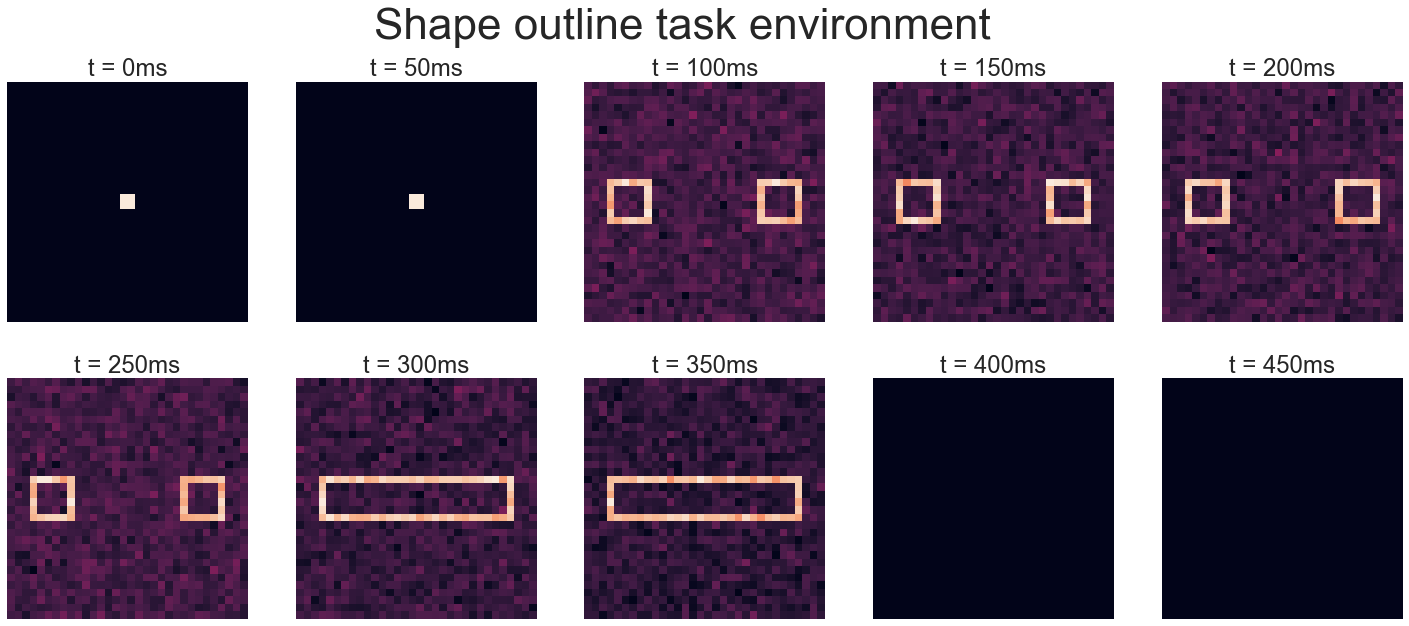

In [8]:
# Create the environment
outline_env = TAMTask(sigma=task_params["sigma"], dt=task_params["dt"], stim_type='outline')
outline_env.reset(no_step=True)
ob = outline_env.ob[0, :, :, :]

# Visualize the environment
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle("Shape outline task environment", fontsize=44)

for i in range(2):
    for j in range(5):

        ax = axes[i, j]

        ax.imshow(ob[0])
        ax.set_title(f't = {outline_env.t}ms')
        ax.axis('off')

        ob, _, _, x = outline_env.step(action=0)  # keep choosing action 0

plt.show()

save_path = Path().cwd().parent / "figures" / "outline_env.png"
fig.savefig(str(save_path))

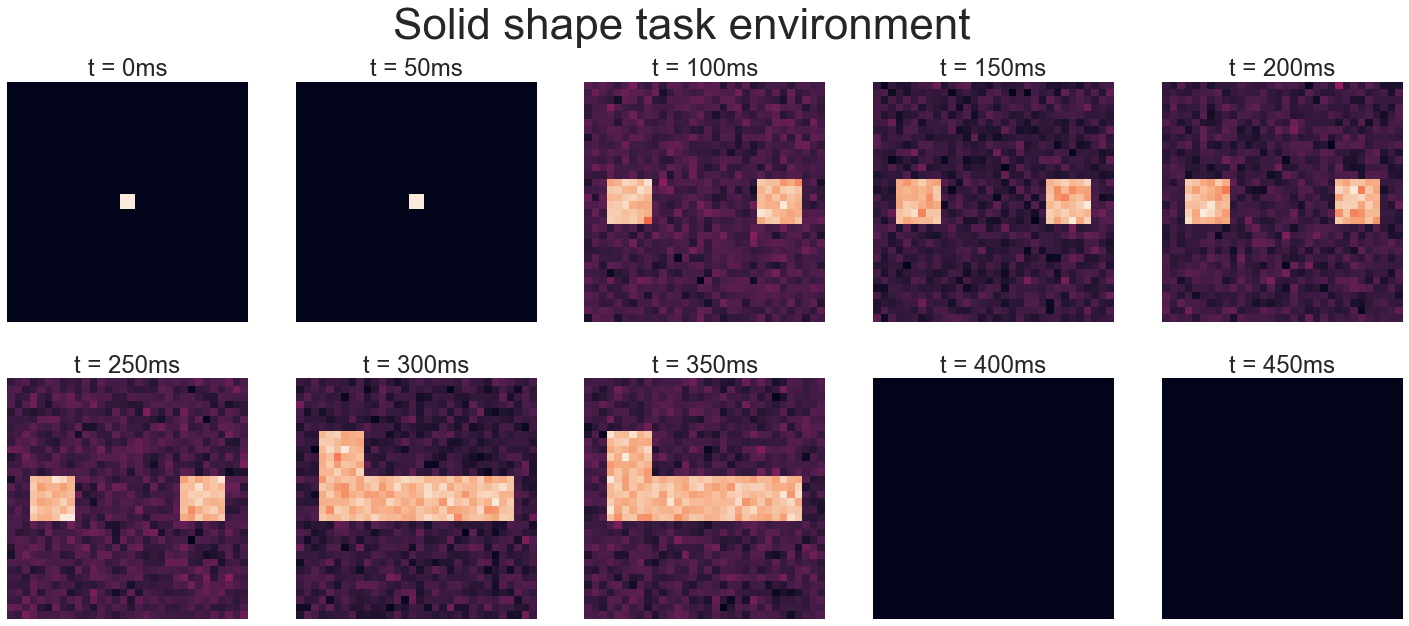

In [21]:
# Create the environment
# solid_env = TAM_env
TAM_env.reset(no_step=True)
ob = TAM_env.ob[0, :, :, :]

# Visualize the environment
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle("Solid shape task environment", fontsize=44)

for i in range(2):
    for j in range(5):

        ax = axes[i, j]

        ax.imshow(ob[0])
        ax.set_title(f't = {TAM_env.t}ms')
        ax.axis('off')

        ob, _, _, x = TAM_env.step(action=0)  # keep choosing action 0


plt.show()

save_path = Path().cwd().parent / "figures" / "solid_env.png"
fig.savefig(str(save_path))

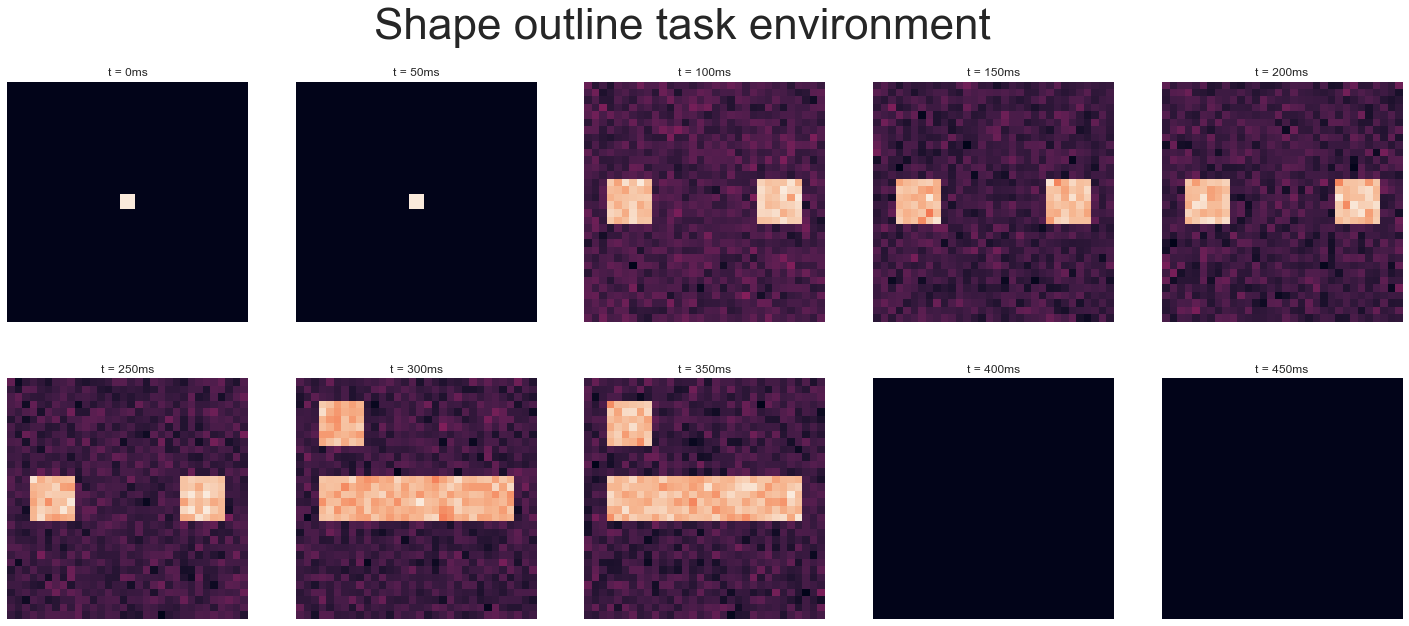

In [6]:
# Create the environment
break_env = TAMTask(sigma=task_params["sigma"], dt=task_params["dt"], stim_type='disjoint')
break_env.reset(no_step=True)
ob = break_env.ob[0, :, :, :]

# Visualize the environment
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle("Shape outline task environment", fontsize=44)

for i in range(2):
    for j in range(5):

        ax = axes[i, j]

        ax.imshow(ob[0])
        ax.set_title(f't = {break_env.t}ms')
        ax.axis('off')

        ob, _, _, x = break_env.step(action=0)  # keep choosing action 0

plt.show()

save_path = Path().cwd().parent / "figures" / "disjoint_env.png"
fig.savefig(str(save_path))

In [7]:
# Generate a dataset
break_dataset = ngym.Dataset(
    break_env,
    batch_size=task_params["batch_size"],
    seq_len=task_params["sequence_length"]
)

# Generate one batch of data when called
inputs, target = break_dataset()
print('Input has shape (SeqLen, Batch, Dim) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Target are the integers, for example target in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, Dim) = (100, 16, 1, 32, 32)
Target has shape (SeqLen, Batch) = (100, 16)
Target are the integers, for example target in the first sequence:
[0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 1
 1 1 1 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0
 0 0 1 1 1 1 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 2 2 2 2]


In [8]:
# Test the model
n_trials = 1000
trial_infos, activity, perf = test_model(TAM_rnn, break_dataset, n_trials, device)
print(f"Performance of the network: {perf}")

Performance of the network: 0.416


In [10]:
# Generate a dataset
outline_dataset = ngym.Dataset(
    outline_env,
    batch_size=task_params["batch_size"],
    seq_len=task_params["sequence_length"]
)

# Generate one batch of data when called
inputs, target = outline_dataset()
print('Input has shape (SeqLen, Batch, Dim) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Target are the integers, for example target in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, Dim) = (100, 16, 1, 32, 32)
Target has shape (SeqLen, Batch) = (100, 16)
Target are the integers, for example target in the first sequence:
[0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 1
 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 2 2 2 2 0 0 0 0
 0 0 2 2 2 2 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 3 3 3 3]


In [11]:
# Test the model
n_trials = 1000
trial_infos, activity, perf = test_model(TAM_rnn, outline_dataset, n_trials, device)
print(f"Performance of the network: {perf}")

Performance of the network: 1.0
